In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import os
from scripts.prepare_scripts import copy_directory_structure, get_valid_paths, process_dataframes
from scripts.preprocessing_scripts import get_class_weights, get_value_weights

# Setting up the environment and file folders

Actions performed in this notebook:

* Cloning the raw file structures to prepare them for image processing
* Extracting class distributions
* Resampling to address class imbalances
* Preprocessing of data frames to track the generated images

In [2]:
# --- Main Directory: contains all folders/files for this project
root = "S:/CheXpert/"

# --- This is the original root listed on the csv file paths
old_root = "CheXpert-v1.0/train/"
old_test_root = "test/"

# --- Input image directory variables
"""
The training set will be from a sample of 80% of instances from batch 2 and 3
The validation set will be from the other 20% of instances from batch 2 and 3
The test set will be batch 4, the smallest of the training datasets

The valid rad (radiologist) and test rad sets are not primarily used, but will serve as how our model performs
against real human annotations

These source_roots are the paths to the folders containing the respective  patient image folders downloaded 
from the blob and organized as specified in the data dictionary.
"""
source_train_root1 = f"{root}raw_data/CheXpert-v1.0 batch 2 (train 1)/"
source_train_root2 = f"{root}raw_data/CheXpert-v1.0 batch 3 (train 2)/"
source_train_root3 = f"{root}raw_data/CheXpert-v1.0 batch 4 (train 3)/"
source_valid_rad_root = f"{root}raw_data/CheXpert-v1.0 batch 1 (validate & csv)/valid/"
source_test_rad_root = f"{root}raw_data/test/"

# --- Input dataframe files
"""
These are the .csv files which contain the metadata pertaining to each image, including limited demographic info.
These .csv files are to contain all paths to each variation of an image.
"""
labels = f"{root}raw_data/train_cheXbert.csv"
valid_rad_labels = f"{root}raw_data/CheXpert-v1.0 batch 1 (validate & csv)/valid.csv"
test_rad_labels = f"{root}raw_data/test_labels.csv"

# --- Output directory variables
"""
These roots are the paths to the folder containing the respective patient folders for each data split.
"""
train_valid_root = f"{root}train_valid/"
test_root = f"{root}test/"
valid_rad_root = f"{root}valid_rad/" 
test_rad_root = f"{root}test_rad/"

# --- Image sizes
dims = [224, 384, 512]

In [3]:
## --- Create new directories (only run this if necessary)
"""
To reduce the memory requirements of working with multiple images, we save each image and only open 
them when necessary. To achieve this, we must set up a file structure to track each image.

This will copy the existing folder structure from the source root folders to the specified new root folders
"""

# Only run this if necessary
run_this_cell = False

if run_this_cell:
    copy_directory_structure(source_train_root1, train_valid)
    copy_directory_structure(source_train_root2, train_valid)
    copy_directory_structure(source_train_root3, test_root)
    copy_directory_structure(source_valid_root, valid_rad_root)
    copy_directory_structure(source_test_rad_root, test_rad_root)

## Load data

In [4]:
# --- Load the training/validation csvs
data_df = pd.read_csv(labels)
valid_rad_df = pd.read_csv(valid_rad_labels)
test_rad_df = pd.read_csv(test_rad_labels)

print(f"# rows in data_df: {len(data_df)}")
print(f"# rows in valid_rad_df: {len(valid_rad_df)}")
print(f"# rows in test_rad_df: {len(test_rad_df)}")

# rows in data_df: 223414
# rows in valid_rad_df: 234
# rows in test_rad_df: 668


## Process data frames

Actions taken to process the data frames:
1) Loop through the specified source_root folder to find all image paths that exist
   1) Store each path string in the valid_paths list
2) For each image metadata row in df, add new path columns:
   1) ```floating_file_path```: The image file path without the root folder (ex: ```S:/Root/patientX/image.jpg``` to ```patientX/image.jpg```)
   2) ```source_file_path```: The file path to the original image saved from the blob
   3) ```base{dim}_file_path```: The file path to the saved dim x dim processed image
   4) ```base{dim}_file_path2```: The file path to the saved enhanced dim x dim processed image
3) Filter out any images whose source_file_path is not contained in the valid_paths (created in step 1)
4) Return the processed dataframes

In [5]:
# --- Split the df into the corresponding train/valid/test sets
train_df1 = process_dataframes(data_df, source_train_root1, old_root, train_valid_root, dims)
train_df2 = process_dataframes(data_df, source_train_root2, old_root, train_valid_root, dims)
# Combine the train_dfs
train_df0 = pd.concat([train_df1, train_df2], axis=0)
# Split into corresponding train/validation sets
train_df, valid_df = train_test_split(train_df0, test_size=0.2)


In [6]:
# --- Process the test, valid rad, and test rad sets
test_df = process_dataframes(data_df, source_train_root3, old_root, test_root, dims)
#
valid_rad_df = process_dataframes(valid_rad_df, source_valid_rad_root, old_root, valid_rad_root, dims)
test_rad_df2 = process_dataframes(test_rad_df, source_test_rad_root, old_root, test_rad_root, dims)

In [7]:
print(f"# rows in train_df: {len(train_df)}")
print(f"# rows in valid_df: {len(valid_df)}")
print(f"# rows in test_df: {len(test_df)}")
print(f"# rows in valid_rad_df: {len(valid_rad_df)}")
print(f"# rows in test_rad_df: {len(test_rad_df)}")
print(f"# rows in test_rad_df: {len(test_rad_df2)}")

# rows in train_df: 145949
# rows in valid_df: 36488
# rows in test_df: 40977
# rows in valid_rad_df: 234
# rows in test_rad_df: 668
# rows in test_rad_df: 0


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145949 entries, 37201 to 8989
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Path                        145949 non-null  object 
 1   Sex                         145949 non-null  object 
 2   Age                         145949 non-null  int64  
 3   Frontal/Lateral             145949 non-null  object 
 4   AP/PA                       121265 non-null  object 
 5   Enlarged Cardiomediastinum  30151 non-null   float64
 6   Cardiomegaly                34104 non-null   float64
 7   Lung Opacity                70415 non-null   float64
 8   Lung Lesion                 8251 non-null    float64
 9   Edema                       55567 non-null   float64
 10  Consolidation               47288 non-null   float64
 11  Pneumonia                   18188 non-null   float64
 12  Atelectasis                 43639 non-null   float64
 13  Pneumothorax     

In [9]:
# valid_df.info()

In [10]:
# test_df.info()

In [11]:
# valid_rad_df.info()

In [12]:
# test_rad_df.info()

In [13]:
### Filter out unnecessary values
train_df = train_df[train_df["Frontal/Lateral"]=="Frontal"].reset_index(drop=True)
valid_df = valid_df[valid_df["Frontal/Lateral"]=="Frontal"].reset_index(drop=True)
test_df = test_df[test_df["Frontal/Lateral"]=="Frontal"].reset_index(drop=True)
valid_rad_df = valid_rad_df[valid_rad_df["Path"].str.find("frontal") > 0].reset_index(drop=True)
test_rad_df = test_rad_df[test_rad_df["Path"].str.find("frontal") > 0].reset_index(drop=True)
# 

# ### Filter out invalid images found during EDA
# filter_out_paths = [f"{source_train_root3}patient48043/study1/view2_frontal.jpg",
#             f"{source_train_root3}patient44163/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient60655/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient52670/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient56384/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient52150/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient46703/study2/view1_frontal.jpg",
#             f"{source_train_root3}patient56024/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient49936/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient50284/study3/view1_frontal.jpg",
#             f"{source_train_root3}patient55832/study2/view1_frontal.jpg",
#             f"{source_train_root3}patient62069/study1/view1_frontal.jpg",
#             f"{source_train_root3}patient43440/study3/view1_frontal.jpg"
#             ]
# train_df = train_df[~train_df["source_file_path"].isin(filter_out_paths)]


# Perform resampling actions to alleviate class imbalances

In [14]:
# Instantiate the list of class columns for general use
class_cols = ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
       'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
       'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
       'Support Devices', 'No Finding']

# Instantiate a list of class columns without "No Finding" to bias weights toward conditions of interest
class_cols_weights = ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
       'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
       'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
       'Support Devices']

In [15]:
### Map the values to 0/1/2 for CrossEntropyLoss usage
for col in class_cols:
    train_df[col] = train_df[col].map(lambda x: 1 if x==1 else 2 if x==-1 else 0)
    valid_df[col] = valid_df[col].map(lambda x: 1 if x==1 else 2 if x==-1 else 0)
    test_df[col] = test_df[col].map(lambda x: 1 if x==1 else 2 if x==-1 else 0)

### View the original distributions

In [16]:
def get_plot_histograms(df, class_cols, suptitle):

    fig,axes = plt.subplots(4,4, figsize=(9,7))
    for i,(col,ax) in enumerate(zip(class_cols, axes.flatten())):
        df[col].hist(ax=ax)
        ax.set_title(col)

    # Turn off unused axes
    for i in range(len(axes.flatten())):
        if i >= len(class_cols):
            axes.flatten()[i].axis("off")
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


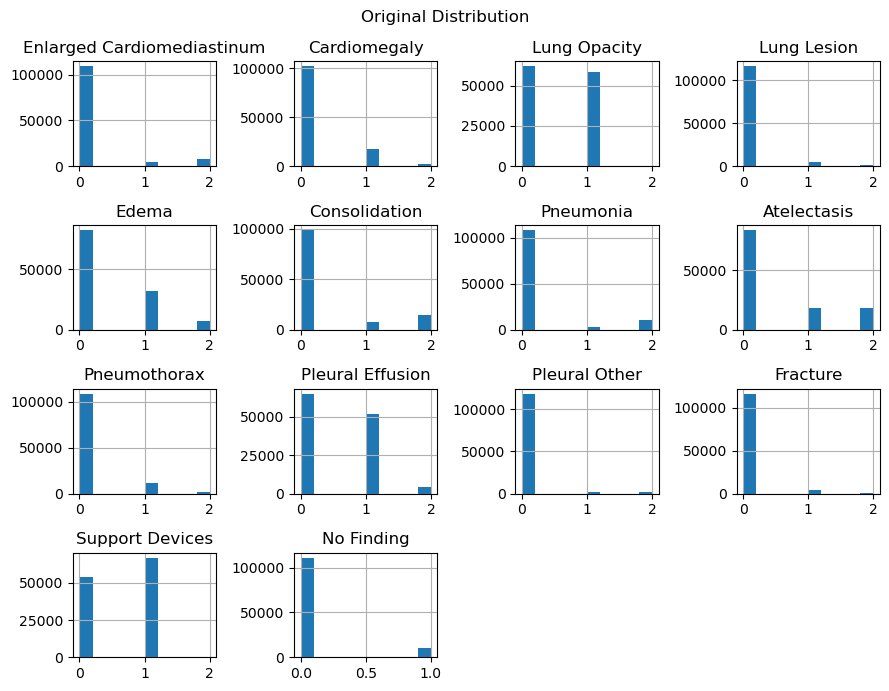

,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
count,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000,121265.000000
mean,0.165373,0.177339,0.487733,0.049998,0.378716,0.307038,0.192916,0.462796,0.114411,0.496384,0.036919,0.041380,0.553663,0.082159
std,0.519713,0.426105,0.502353,0.246426,0.591190,0.673864,0.572571,0.746625,0.353631,0.563071,0.238049,0.209698,0.497727,0.274608
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000


In [17]:
get_plot_histograms(train_df, class_cols, "Original Distribution")
train_df[class_cols].describe()

### Get weights based on the original training distributions

These are used to affect the loss function aggregations, as well as to increase weight for non-zero class values

In [18]:
### Get class probabilities --> For each class, what is the probability of a non-zero value?
"""
This is used to increase the weight for the most imbalanced class columns when summing the loss functions. This
is also used to increase the chance of selecting imbalanced class columns when resampling
"""
classWeights_train = get_class_weights(train_df, class_cols)
for weight,class_col in zip(classWeights_train, class_cols):
    print(f"{class_col}: {weight}")

Enlarged Cardiomediastinum: 0.06630232181623034
Cardiomegaly: 0.04129240867533403
Lung Opacity: 0.013538517596974399
Lung Lesion: 0.15181101855128507
Edema: 0.020478917143546427
Consolidation: 0.03533816063883505
Pneumonia: 0.06164063970041759
Atelectasis: 0.021357304754474025
Pneumothorax: 0.06422820817035067
Pleural Effusion: 0.014229578260374692
Pleural Other: 0.24982100988373812
Fracture: 0.16789526352707815
Support Devices: 0.011902266196717148
No Finding: 0.08016438508464427


In [19]:
### Get class value probabilities
"""
This is used to increase the sample size for certain class values
"""
valueWeights_train = get_value_weights(train_df, class_cols)
for weight,val in zip(valueWeights_train, [0,1,2]):
    print(f"{val}: {weight}")

0: 0.04005809493653378
1: 0.1831942490851061
2: 0.7767476559783602


### Get 3 sets of resampled datasets emphasizing underrepresented classes

Though only the oversampled version is used in ths project, the smaller datasets provide reduced variations for model testing. The code is shown here below for direct reference

In [20]:
def resample(df, class_cols, n_samples, concat_with_original_df, classWeights, valueWeights):
    def get_weighted_sampled_index(df, class_cols, n_samples, classWeights, valueWeights):
        """
        Given the input parameters, resample from df with replacement with this criteria:
            1) Columns that are more imbalanced have a higher probability of being chosen
            2) Values that are more imbalanced have a higher probability of being chosen
        For example, sample 1 may be an image where "Pleural Other" is "2"
    
        For this, don't include the weights for 0 --> Only sample when the value==1 or value==2
    
        Return results as a batch of image indexes from df
        """
        batch = []
        # For each sample index, get the column and value to create a df subset
        col_sample = np.random.choice(len(class_cols),
                                      size=n_samples,
                                      replace=True,
                                      p=classWeights)
        val_sample = np.random.choice([1,2],
                                      size=n_samples,
                                      replace=True,
                                      p=valueWeights[1:]/valueWeights[1:].sum())
        
        for i,(col_samp, val_samp) in enumerate(zip(col_sample, val_sample)):
            # Cover edge case of no uncertain "No Finding"
            if col_samp == len(class_cols) - 1:
                val_samp = 1
                
            # Retrieve a random instance where the specified column has the specified value
            subset_df = df[class_cols[col_samp]]
            subset_df = subset_df[subset_df == val_samp]
            if len(subset_df) == 0:
                continue
            elif len(subset_df) == 1:
                row_idx = subset_df.index[0]
            else:
                row_idx = subset_df.sample(1).index[0]
            #
            batch.append(row_idx)
    
        return batch

    def get_and_print_new_weights(df, class_cols, n_samples):
        ### Get class and value weights
        print(f"New class weights for {n_samples} samples")
        classWeights0 = get_class_weights(df, class_cols)
        for weight,class_col in zip(classWeights0, class_cols):
            print(f"{class_col}: {weight}")
            
        print()
        
        print(f"New value weights for {n_samples} samples")
        valueWeights0 = get_value_weights(df, class_cols)
        for weight,val in zip(valueWeights0, [0,1,2]):
            print(f"{val}: {weight}")
    
        return (classWeights0, valueWeights0)

    #
    batch = get_weighted_sampled_index(df, 
                                       class_cols,
                                       n_samples,
                                       classWeights,
                                       valueWeights)
    #
    if concat_with_original_df:
        output_df = pd.concat([df.loc[batch,:], df], axis=0).reset_index(drop=True)
    else:
        output_df = df.loc[batch,:]
    #
    classWeights2, valueWeights2 = get_and_print_new_weights(output_df, class_cols, n_samples)

    return (output_df, classWeights2, valueWeights2)


In [29]:
### Reduce the size of train_df by 30000
train_df_filtered = train_df.sample(len(train_df) - 60000)

New class weights for 5000 samples
Enlarged Cardiomediastinum: 0.08648006823366212
Cardiomegaly: 0.09390633448087408
Lung Opacity: 0.029478423258778738
Lung Lesion: 0.07159490337401382
Edema: 0.06174897403933616
Consolidation: 0.06342410991131066
Pneumonia: 0.08659051531952885
Atelectasis: 0.047181888305630554
Pneumothorax: 0.11873970839788284
Pleural Effusion: 0.03205691418212345
Pleural Other: 0.049237744005222295
Fracture: 0.06834715070079747
Support Devices: 0.03317043713071972
No Finding: 0.15804282866011912

New value weights for 5000 samples
0: 0.07040611082883164
1: 0.3834268051386958
2: 0.5461670840324725


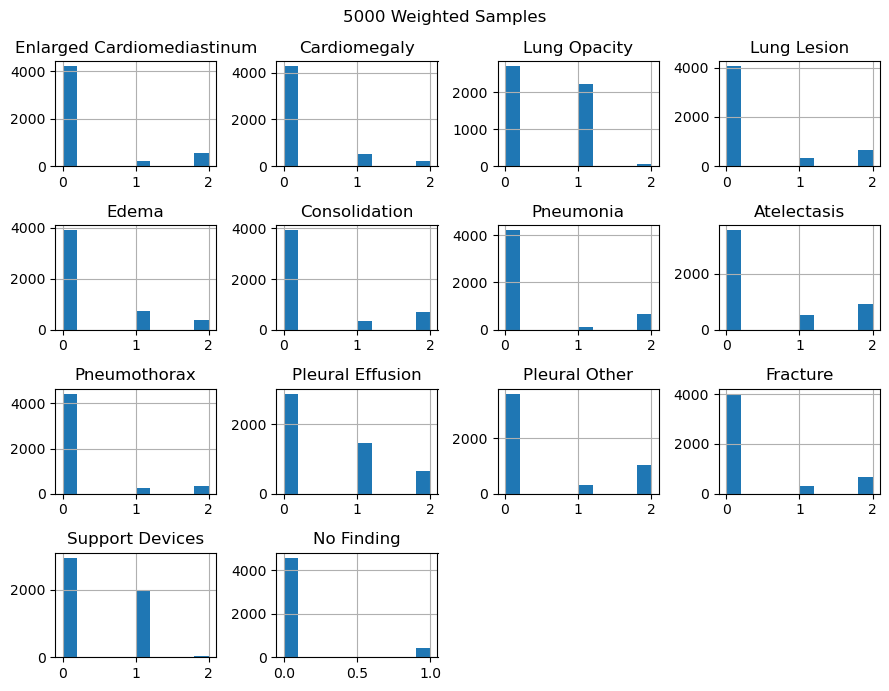

CPU times: total: 1.77 s
Wall time: 1.77 s


In [30]:
%%time
input_df = train_df_filtered.copy()
n_samples = 5000
concat_with_original_df=False
#
outputs = resample(input_df, 
                   class_cols,
                   n_samples,
                   concat_with_original_df, 
                   classWeights_train, 
                   valueWeights_train)
train_df_5000, classWeights_train5000, valueWeights_train5000 = outputs
#
get_plot_histograms(train_df_5000, class_cols, f"{n_samples} Weighted Samples")
# output_df[class_cols].describe()

New class weights for 30000 samples
Enlarged Cardiomediastinum: 0.08806213720376267
Cardiomegaly: 0.09037591893581752
Lung Opacity: 0.029137269549753507
Lung Lesion: 0.06855944923700093
Edema: 0.06311856446380104
Consolidation: 0.06570513747284823
Pneumonia: 0.08885934356838053
Atelectasis: 0.046823032812239145
Pneumothorax: 0.10924103339337553
Pleural Effusion: 0.03233780369796669
Pleural Other: 0.04881658988612269
Fracture: 0.06526823986720652
Support Devices: 0.03324060188495873
No Finding: 0.17045487802676637

New value weights for 30000 samples
0: 0.06982102121667146
1: 0.3834786607015881
2: 0.5467003180817405


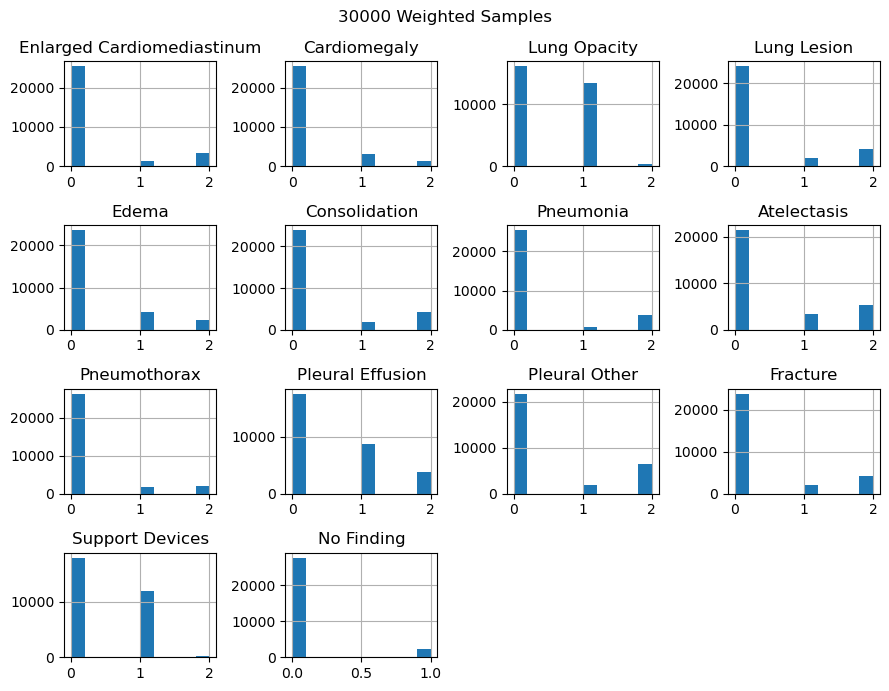

CPU times: total: 6.84 s
Wall time: 6.83 s


In [31]:
%%time
input_df = train_df_filtered.copy()
n_samples = 30000
concat_with_original_df=False
#
outputs = resample(input_df, 
                   class_cols,
                   n_samples,
                   concat_with_original_df, 
                   classWeights_train, 
                   valueWeights_train)
train_df_30000, classWeights_train30000, valueWeights_train30000 = outputs
#
get_plot_histograms(train_df_30000, class_cols, f"{n_samples} Weighted Samples")
# output_df[class_cols].describe()

New class weights for 60000 samples
Enlarged Cardiomediastinum: 0.08864268929197419
Cardiomegaly: 0.09023017238163022
Lung Opacity: 0.029350843062230195
Lung Lesion: 0.06907683298227504
Edema: 0.06344694952763831
Consolidation: 0.06507053182342819
Pneumonia: 0.0873445945634603
Atelectasis: 0.04637107698570033
Pneumothorax: 0.11380039979108526
Pleural Effusion: 0.0323988197352261
Pleural Other: 0.04882150163772831
Fracture: 0.06622871078632069
Support Devices: 0.03373967430791348
No Finding: 0.1654772031233896

New value weights for 60000 samples
0: 0.07013419915154717
1: 0.3823502437461596
2: 0.547515557102293


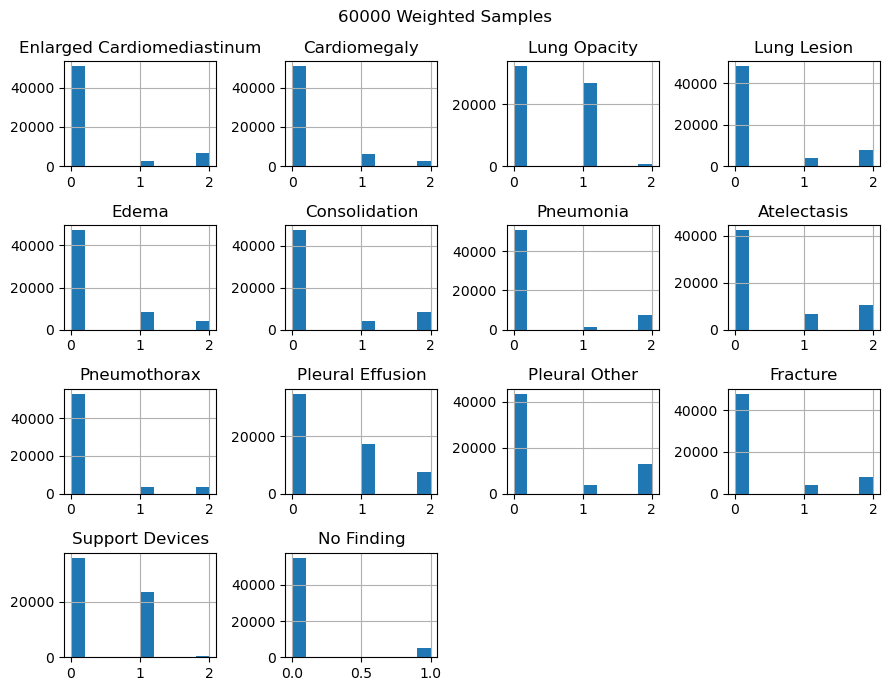

CPU times: total: 13.1 s
Wall time: 13.1 s


In [32]:
%%time
input_df = train_df_filtered.copy()
n_samples = 60000
concat_with_original_df=False
#
outputs = resample(input_df, 
                   class_cols,
                   n_samples,
                   concat_with_original_df, 
                   classWeights_train, 
                   valueWeights_train)
train_df_60000, classWeights_train60000, valueWeights_train60000 = outputs
#
get_plot_histograms(train_df_60000, class_cols, f"{n_samples} Weighted Samples")
# output_df[class_cols].describe()

New class weights for 60000 samples
Enlarged Cardiomediastinum: 0.09273901894083425
Cardiomegaly: 0.07556347995834352
Lung Opacity: 0.02475835132791046
Lung Lesion: 0.09876279398064197
Edema: 0.04392039544080313
Consolidation: 0.05985775412396377
Pneumonia: 0.09025504343669304
Atelectasis: 0.03929066561618405
Pneumothorax: 0.10669590649352748
Pleural Effusion: 0.02651642565865311
Pleural Other: 0.07839027312471357
Fracture: 0.09633497030680031
Support Devices: 0.02429616490671088
No Finding: 0.1426187566842205

New value weights for 60000 samples
0: 0.05794900660984008
1: 0.2879145555440906
2: 0.6541364378460693


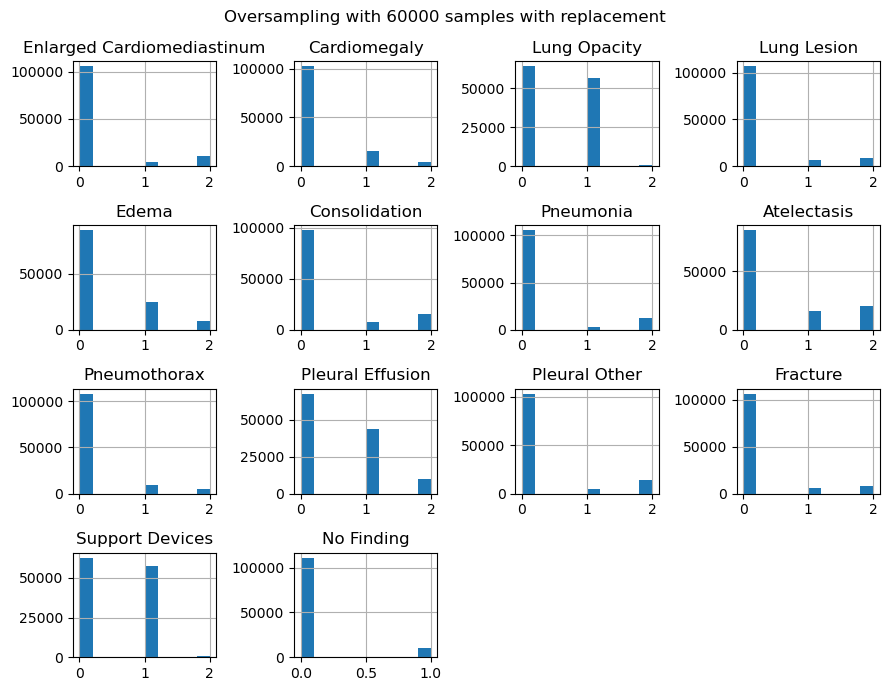

CPU times: total: 13.6 s
Wall time: 13.6 s


In [33]:
%%time
input_df = train_df_filtered.copy()
n_samples = 60000
concat_with_original_df=True
#
outputs = resample(input_df, 
                   class_cols,
                   n_samples,
                   concat_with_original_df, 
                   classWeights_train, 
                   valueWeights_train)
train_df_oversampled, classWeights_train_oversampled, valueWeights_train_oversampled = outputs
#
get_plot_histograms(train_df_oversampled, class_cols, f"Oversampling with {n_samples} samples with replacement")
# output_df[class_cols].describe()

In [35]:
print(f"# rows in train_df: {len(train_df)}")
print(f"# rows in train_df_5000: {len(train_df_5000)}")
print(f"# rows in train_df_30000: {len(train_df_30000)}")
print(f"# rows in train_df_60000: {len(train_df_60000)}")
print(f"# rows in train_df_oversampled: {len(train_df_oversampled)}")
print(f"# rows in valid_df: {len(valid_df)}")
print(f"# rows in test_df: {len(test_df)}")
print(f"# rows in valid_rad_df: {len(valid_rad_df)}")
print(f"# rows in test_rad_df: {len(test_rad_df)}")

# rows in train_df: 121265
# rows in train_df_5000: 5000
# rows in train_df_30000: 30000
# rows in train_df_60000: 60000
# rows in train_df_oversampled: 121265
# rows in valid_df: 30391
# rows in test_df: 39371
# rows in valid_rad_df: 202
# rows in test_rad_df: 518


In [36]:
### Save new training, validation, test csvs
train_df.to_csv(f"{root}train_df.csv", index=False)
train_df_5000.to_csv(f"{root}train_df_5000.csv", index=False)
train_df_30000.to_csv(f"{root}train_df_30000.csv", index=False)
train_df_60000.to_csv(f"{root}train_df_60000.csv", index=False)
train_df_oversampled.to_csv(f"{root}train_df_oversampled.csv", index=False)
#
valid_df.to_csv(f"{root}valid_df.csv", index=False)
test_df.to_csv(f"{root}test_df.csv", index=False)
#
valid_rad_df.to_csv(f"{root}valid_rad_df.csv", index=False)
test_rad_df.to_csv(f"{root}test_rad_df.csv", index=False)

In [37]:
### Save the weights
classWeights = {5000:classWeights_train5000,
                30000:classWeights_train30000,
                60000:classWeights_train60000,
                120000:classWeights_train_oversampled,
                "train_df":classWeights_train
     }

valueWeights = {5000:valueWeights_train5000,
                30000:valueWeights_train30000,
                60000:valueWeights_train60000,
                120000:valueWeights_train_oversampled,
                "train_df":valueWeights_train
     }

pd.DataFrame(classWeights).to_csv(f"{root}classWeights.csv", index=False)
pd.DataFrame(valueWeights).to_csv(f"{root}valueWeights.csv", index=False)

print(classWeights)
print()
print(valueWeights)

{5000: Enlarged Cardiomediastinum    0.086480
Cardiomegaly                  0.093906
Lung Opacity                  0.029478
Lung Lesion                   0.071595
Edema                         0.061749
Consolidation                 0.063424
Pneumonia                     0.086591
Atelectasis                   0.047182
Pneumothorax                  0.118740
Pleural Effusion              0.032057
Pleural Other                 0.049238
Fracture                      0.068347
Support Devices               0.033170
No Finding                    0.158043
dtype: float64, 30000: Enlarged Cardiomediastinum    0.088062
Cardiomegaly                  0.090376
Lung Opacity                  0.029137
Lung Lesion                   0.068559
Edema                         0.063119
Consolidation                 0.065705
Pneumonia                     0.088859
Atelectasis                   0.046823
Pneumothorax                  0.109241
Pleural Effusion              0.032338
Pleural Other                 0.04